In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('lithium-ion batteries.csv')
df.head()

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Materials Id           339 non-null    object 
 1   Formula                339 non-null    object 
 2   Spacegroup             339 non-null    object 
 3   Formation Energy (eV)  339 non-null    float64
 4   E Above Hull (eV)      339 non-null    float64
 5   Band Gap (eV)          339 non-null    float64
 6   Nsites                 339 non-null    int64  
 7   Density (gm/cc)        339 non-null    float64
 8   Volume                 339 non-null    float64
 9   Has Bandstructure      339 non-null    bool   
 10  Crystal System         339 non-null    object 
dtypes: bool(1), float64(5), int64(1), object(4)
memory usage: 26.9+ KB


<Axes: >

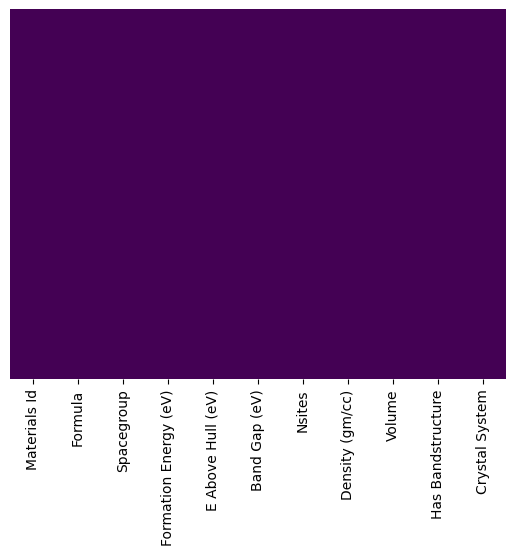

In [4]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

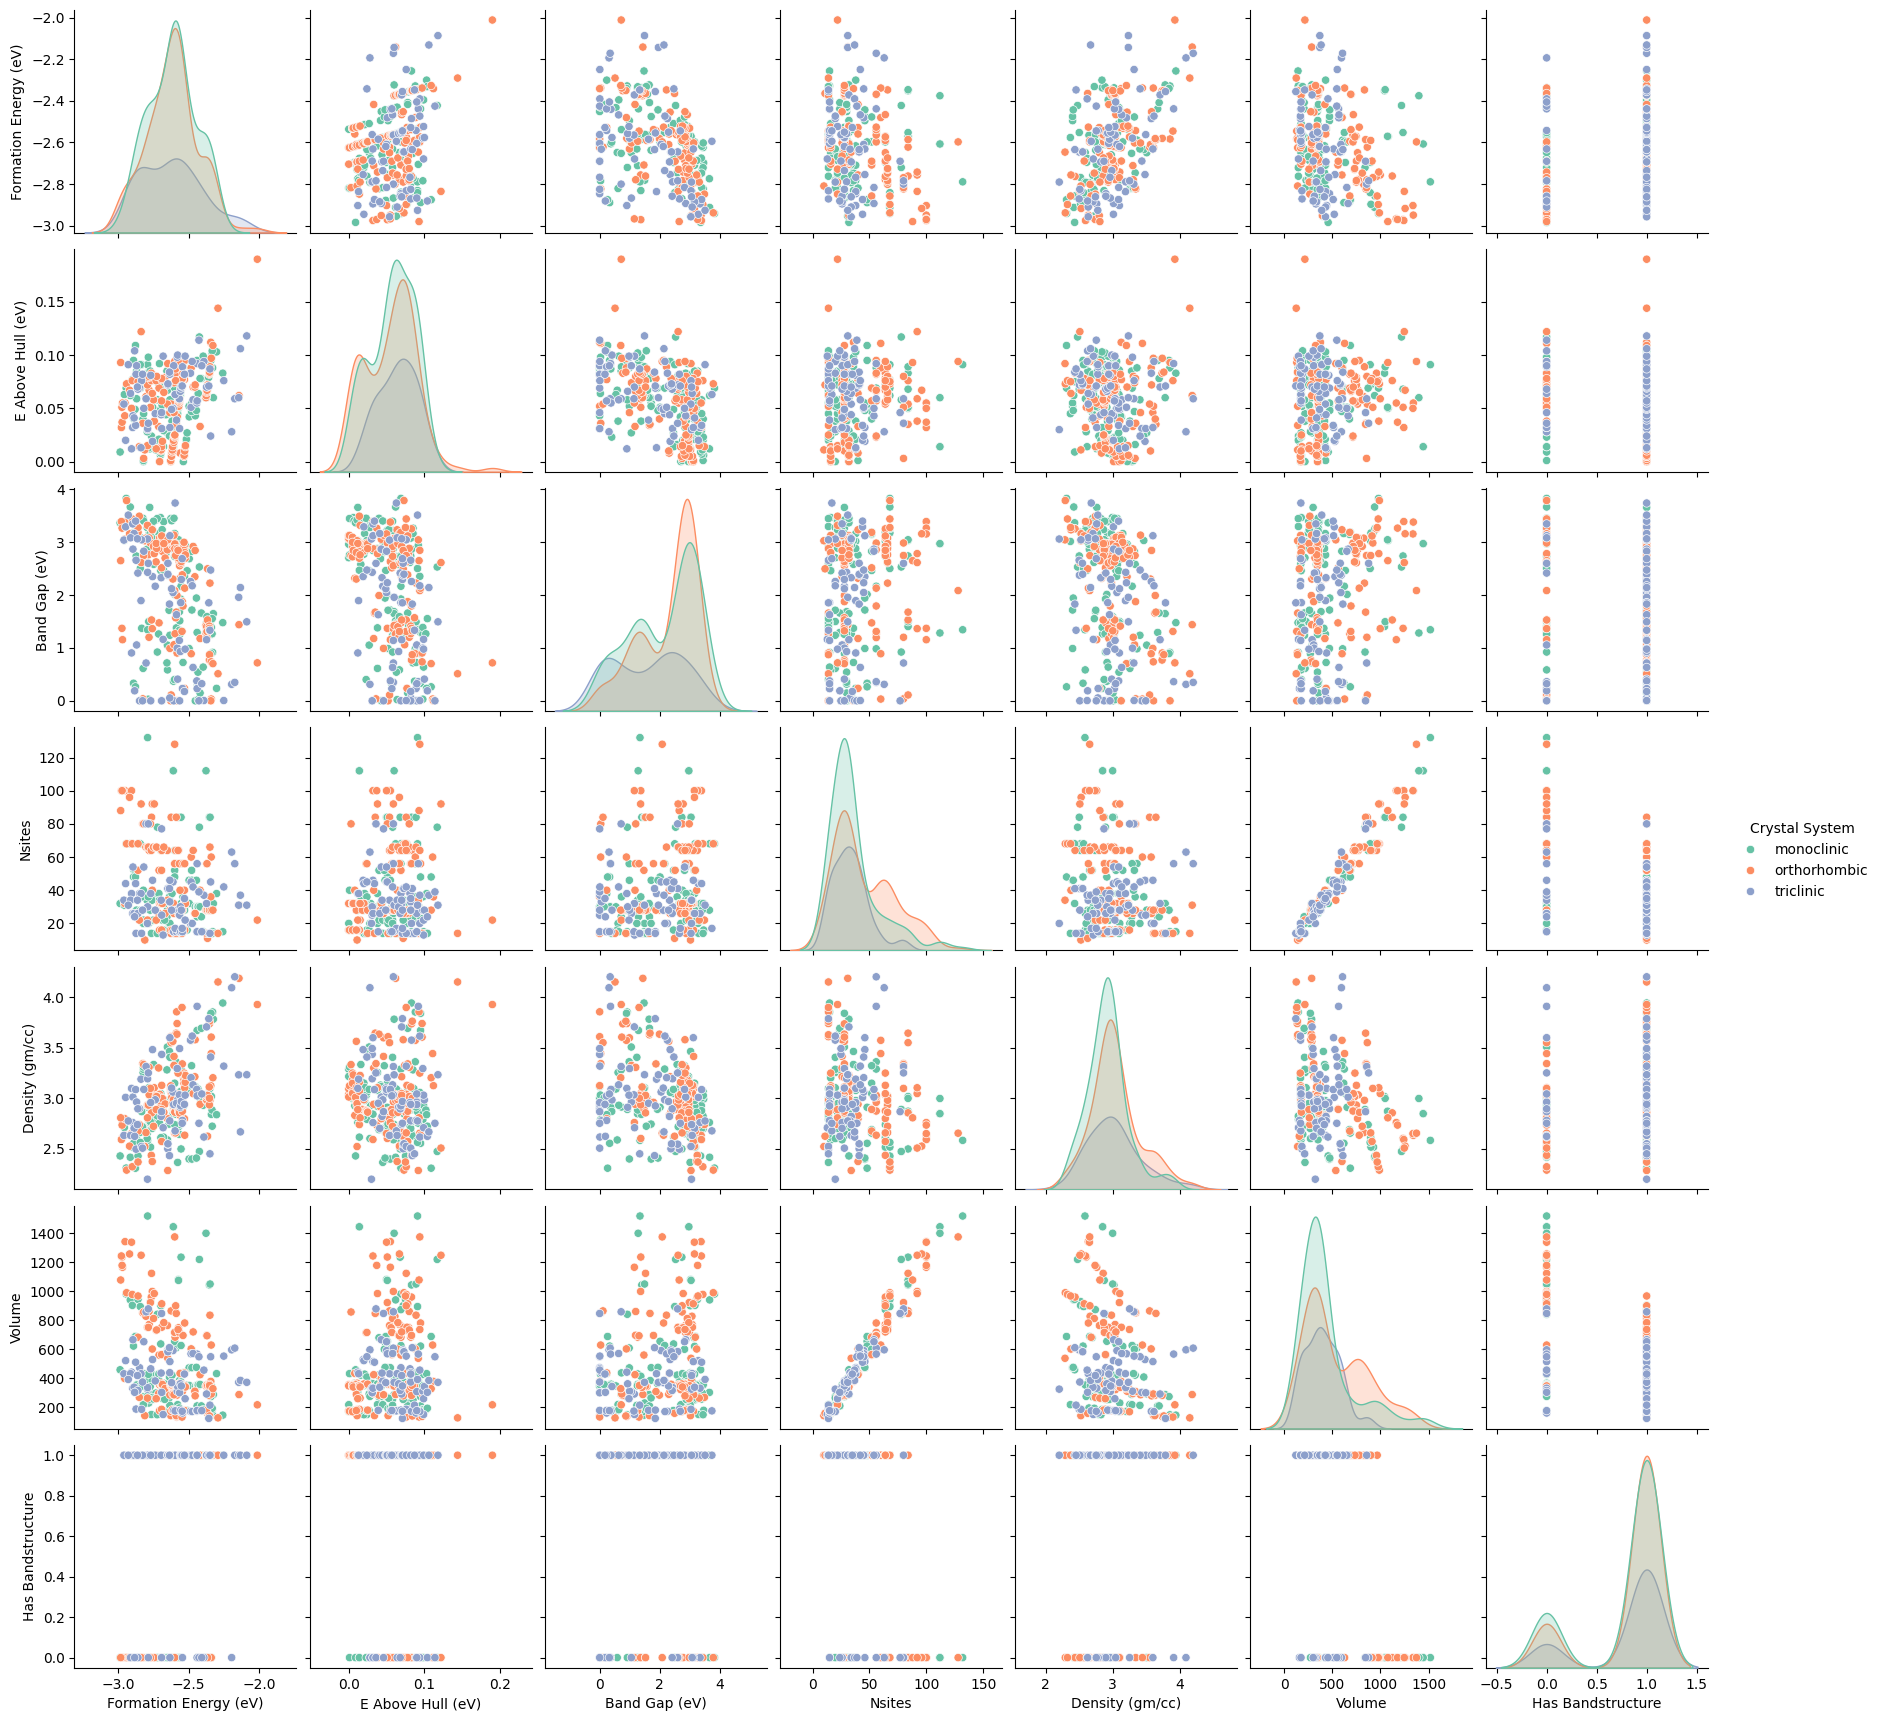

In [5]:
sns.pairplot(df,hue='Crystal System',palette='Set2')

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Load data
file_path = 'lithium-ion batteries.csv'
df = pd.read_csv(file_path)

# Drop leakage-heavy or disallowed columns
for col in ['Spacegroup']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Target
TARGET = 'Crystal System'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(verbose=0)
}

param_grids = {
    'Random Forest': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10]
    },
        'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.05, 0.1]
    },
    'CatBoost': {
        'model__depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__iterations': [200, 400]
    }
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Running {name}...')

    pipe = ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    if name in param_grids:
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grids[name],
            n_iter=10,
            cv=cv,
            scoring='accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        best_model = pipe.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    ROC_AUC= roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'ROC_AUC': round(ROC_AUC, 4)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('\nFinal optimized comparison without Spacegroup:')
print(results_df)

Running Logistic Regression...
Running Decision Tree...
Running Random Forest...
Running KNN...
Running SVM...
Running Gradient Boosting...
Running AdaBoost...
Running Naive Bayes...
Running XGBoost...
Running CatBoost...

Final optimized comparison without Spacegroup:
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
8              XGBoost    0.6471     0.6452  0.6471  0.6454   0.8124
2        Random Forest    0.6324     0.6440  0.6324  0.6277   0.7929
9             CatBoost    0.6324     0.6294  0.6324  0.6302   0.7930
5    Gradient Boosting    0.6176     0.6195  0.6176  0.6180   0.8153
6             AdaBoost    0.6176     0.6218  0.6176  0.6181   0.7622
1        Decision Tree    0.6029     0.5999  0.6029  0.5955   0.6891
3                  KNN    0.5735     0.5733  0.5735  0.5684   0.7333
4                  SVM    0.5294     0.5135  0.5294  0.5171   0.7017
0  Logistic Regression    0.4706     0.4558  0.4706  0.4612   0.6723
7          Naive Bayes    0.3529     0.4

In [11]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("lithium-ion batteries.csv")

# -----------------------------
# Parse formula into element counts
# -----------------------------
def parse_formula_counts(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    counts = {}
    for el, num in tokens:
        counts[el] = counts.get(el, 0) + (int(num) if num else 1)
    return counts

elements = ["Li", "Co", "Fe", "Mn", "Si", "O"]

for el in elements:
    df[el] = df["Formula"].apply(lambda x: parse_formula_counts(x).get(el, 0))

df["TM_total"] = df[["Co", "Fe", "Mn"]].sum(axis=1)
df["Li_to_Si"] = df["Li"] / df["Si"].replace(0, np.nan)
df["TM_to_Si"] = df["TM_total"] / df["Si"].replace(0, np.nan)
df["O_to_Si"] = df["O"] / df["Si"].replace(0, np.nan)
df["Li_to_TM"] = df["Li"] / df["TM_total"].replace(0, np.nan)

# -----------------------------
# Target
# -----------------------------
y = df["Crystal System"]
y = LabelEncoder().fit_transform(y) # Add this line to encode target variable

# -----------------------------
# Features
# Keep Formula-derived features, but remove Spacegroup
# -----------------------------
feature_cols = [
    "Formation Energy (eV)",
    "E Above Hull (eV)",
    "Band Gap (eV)",
    "Nsites",
    "Density (gm/cc)",
    "Volume",
    "Has Bandstructure",
    "Li", "Co", "Fe", "Mn", "Si", "O",
    "TM_total", "Li_to_Si", "TM_to_Si", "O_to_Si", "Li_to_TM"
]

X = df[feature_cols].copy()

X["Has Bandstructure"] = X["Has Bandstructure"].replace({
    "TRUE": 1, "FALSE": 0, True: 1, False: 0
}).astype(float)

# -----------------------------
# Models
# -----------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
        "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_state=42
    )
}

# -----------------------------
# CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
    "roc_auc": "roc_auc_ovr"
}

rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)

    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean()
    })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
print(results.round(4))

/tmp/ipykernel_723/264626401.py:65: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Has Bandstructure"] = X["Has Bandstructure"].replace({


               Model  Accuracy  Precision  Recall      F1  ROC_AUC
2            XGBoost    0.6724     0.7018  0.6559  0.6653   0.8292
0      Random Forest    0.6576     0.6698  0.6606  0.6600   0.8281
1  Gradient Boosting    0.6546     0.6723  0.6386  0.6397   0.8175
3           CatBoost    0.6457     0.6658  0.6344  0.6396   0.8217


In [18]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("lithium-ion batteries.csv")

import re
import numpy as np
import pandas as pd

# -----------------------------
# Parse chemical formula
# -----------------------------
def parse_formula_counts(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    counts = {}
    for el, num in tokens:
        counts[el] = counts.get(el, 0) + (int(num) if num else 1)
    return counts

all_counts = df["Formula"].apply(parse_formula_counts)

# -----------------------------
# Build full element vocabulary
# -----------------------------
element_vocab = sorted(set().union(*all_counts))

for el in element_vocab:
    df[f"el_{el}"] = all_counts.apply(lambda x: x.get(el, 0))

# -----------------------------
# Chemistry groups
# -----------------------------
transition_metals = {"Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn"}
alkali_metals = {"Li","Na","K","Rb","Cs"}
non_metals = {"H","C","N","O","F","P","S","Cl","Se","Br","I"}

# -----------------------------
# Formula statistics
# -----------------------------
def formula_stats(counts):
    vals = np.array(list(counts.values()), dtype=float)
    total_atoms = vals.sum() if len(vals) else 0

    return pd.Series({
        "num_unique_elements": len(counts),
        "total_atoms": total_atoms,
        "max_stoich": vals.max() if len(vals) else 0,
        "min_stoich": vals.min() if len(vals) else 0,
        "mean_stoich": vals.mean() if len(vals) else 0,
        "std_stoich": vals.std() if len(vals) else 0,

        "tm_count": sum(counts.get(e, 0) for e in transition_metals),
        "alkali_count": sum(counts.get(e, 0) for e in alkali_metals),
        "nonmetal_count": sum(counts.get(e, 0) for e in non_metals),

        "frac_Li": counts.get("Li", 0) / total_atoms if total_atoms else 0,
        "frac_O": counts.get("O", 0) / total_atoms if total_atoms else 0,
        "frac_P": counts.get("P", 0) / total_atoms if total_atoms else 0,
        "frac_F": counts.get("F", 0) / total_atoms if total_atoms else 0,

        "has_Li": int("Li" in counts),
        "has_O": int("O" in counts),
        "has_P": int("P" in counts),
        "has_F": int("F" in counts),
        "has_Ni": int("Ni" in counts),
        "has_Co": int("Co" in counts),
        "has_Mn": int("Mn" in counts),
        "has_Fe": int("Fe" in counts),
        "has_Ti": int("Ti" in counts),
        "has_V": int("V" in counts),
        "has_Si": int("Si" in counts),
    })

formula_df = all_counts.apply(formula_stats)
df = pd.concat([df, formula_df], axis=1)

# -----------------------------
# High-value ratios
# -----------------------------
df["Li_to_tm"] = df["el_Li"] / df["tm_count"].replace(0, np.nan)
df["O_to_tm"] = df["el_O"] / df["tm_count"].replace(0, np.nan)
df["Li_to_O"] = df["el_Li"] / df["el_O"].replace(0, np.nan)
df["tm_to_total"] = df["tm_count"] / df["total_atoms"].replace(0, np.nan)

# -----------------------------
# Target
# -----------------------------
y = df["Crystal System"]
y = LabelEncoder().fit_transform(y) # Add this line to encode target variable

# -----------------------------
# Features
# Keep Formula-derived features, but remove Spacegroup
# -----------------------------
feature_cols = [
    "Formation Energy (eV)",
    "E Above Hull (eV)",
    "Band Gap (eV)",
    "Nsites",
    "Density (gm/cc)",
    "Volume",
    "Has Bandstructure",
    "el_Li", "el_Co", "el_Fe", "el_Mn", "el_Si", "el_O", # Updated element counts
    "tm_count", "Li_to_tm", "O_to_tm", "Li_to_O", "tm_to_total", # New TM count and ratios
    "num_unique_elements", "total_atoms", "max_stoich", "min_stoich", "mean_stoich", "std_stoich",
    "alkali_count", "nonmetal_count", "frac_Li", "frac_O", "frac_P", "frac_F",
    "has_Li", "has_O", "has_P", "has_F", "has_Ni", "has_Co", "has_Mn", "has_Fe", "has_Ti", "has_V", "has_Si"
]

X = df[feature_cols].copy()

X["Has Bandstructure"] = X["Has Bandstructure"].replace({
    "TRUE": 1, "FALSE": 0, True: 1, False: 0
}).astype(float)

# -----------------------------
# Models
# -----------------------------
models = {
       "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        verbose=False,
        random_state=42
    ),


}

# -----------------------------
# CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
    "roc_auc": "roc_auc_ovr"
}

rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)

    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean()
    })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
print(results.round(4))

/tmp/ipykernel_723/508817441.py:127: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Has Bandstructure"] = X["Has Bandstructure"].replace({


               Model  Accuracy  Precision  Recall      F1  ROC_AUC
1            XGBoost    0.6812     0.7059   0.670  0.6776   0.8360
0  Gradient Boosting    0.6694     0.6926   0.654  0.6636   0.8411
2           CatBoost    0.6517     0.6807   0.648  0.6564   0.8275


In [19]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = StackingClassifier(
    estimators=[

        ('xgb', XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            eval_metric='mlogloss',
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=500,
            random_state=42
        )),
        ('cat', CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            verbose=0
        ))
    ],
    final_estimator=LogisticRegression(max_iter=3000),
    cv=5,
    n_jobs=-1
)

stack_pipe = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', stack_model)
])

stack_pipe.fit(X_train, y_train)
y_pred = stack_pipe.predict(X_test)
y_pred_proba = stack_pipe.predict_proba(X_test)

print("Stacking Accuracy:", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred, average='weighted'), 4))
print("Recall:", round(recall_score(y_test, y_pred, average='weighted'), 4))
print("F1:", round(f1_score(y_test, y_pred, average='weighted'), 4))
print("ROC_AUC:", round(roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr'), 4))

Stacking Accuracy: 0.7206
Precision: 0.7204
Recall: 0.7206
F1: 0.7162
ROC_AUC: 0.8379


In [20]:
!pip freeze > requirements.txt